### Module Import

In [32]:
!pip install folium

In [33]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import haversine_distances
from math import radians
import folium
from folium.plugins import MarkerCluster

In [4]:
# 코드 실행 후 런타임 재시작 후 다시 코드 실행해야함
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

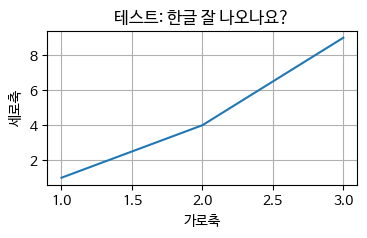

In [5]:
plt.figure(figsize=(4,2))
plt.title("테스트: 한글 잘 나오나요?")
plt.plot([1, 2, 3], [1, 4, 9])
plt.xlabel("가로축")
plt.ylabel("세로축")
plt.grid()
plt.show()

### Data load

In [2]:
df = pd.read_excel("/content/drive/MyDrive/소방안전 공모전/250805_final.xlsx")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10623 entries, 0 to 10622
Data columns (total 36 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   표준버스정류장ID        10623 non-null  int64  
 1   버스정류장ARS번호       10623 non-null  int64  
 2   승차총승객수           10623 non-null  int64  
 3   하차총승객수           10623 non-null  int64  
 4   X좌표              10623 non-null  float64
 5   Y좌표              10623 non-null  float64
 6   정류소타입            10623 non-null  object 
 7   승차_ID            10376 non-null  float64
 8   총환승수             10376 non-null  float64
 9   가중평균환승시간         10376 non-null  float64
 10  스마트쉘터여부          10623 non-null  int64  
 11  동                10623 non-null  object 
 12  전체_인구수           10623 non-null  int64  
 13  65세이상_인구수        10623 non-null  int64  
 14  65세이상_인구비율       10623 non-null  float64
 15  국민기초_수급자수        10623 non-null  int64  
 16  국민기초_수급자비율       10623 non-null  float64
 17  자외선지수_평균    

### Data filtering

In [6]:
df.loc[df['정류소타입'] == '중앙차로', '5m 여부'] = 1
print(df[df['정류소타입'] == '중앙차로']['5m 여부'].unique())

[1]


In [7]:
df['반경500m_수용가능인원합'] = df['반경500m_수용가능인원합'].fillna(0)

In [8]:
# 필요한 열들의 Q1 계산
q1_승차총승객수 = df['승차총승객수'].quantile(0.25)
q1_총환승수 = df['총환승수'].quantile(0.25)
q1_가중평균환승시간 = df['가중평균환승시간'].quantile(0.25)

# 조건을 모두 만족하는 행만 필터링
df = df[
    (df['승차총승객수'] >= q1_승차총승객수) &
    (df['총환승수'] >= q1_총환승수) &
    (df['가중평균환승시간'] >= q1_가중평균환승시간)
]

print(len(df))

4872


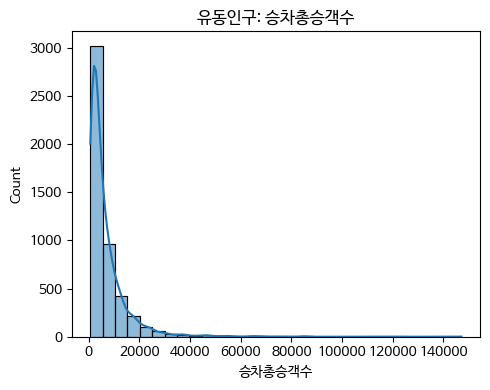

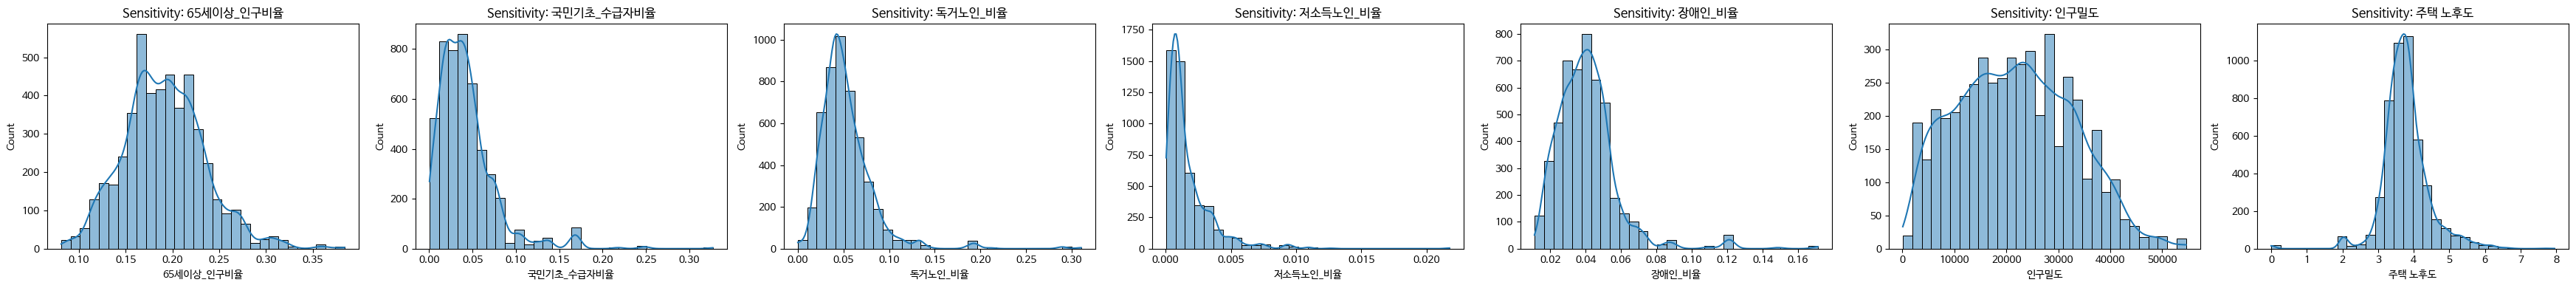

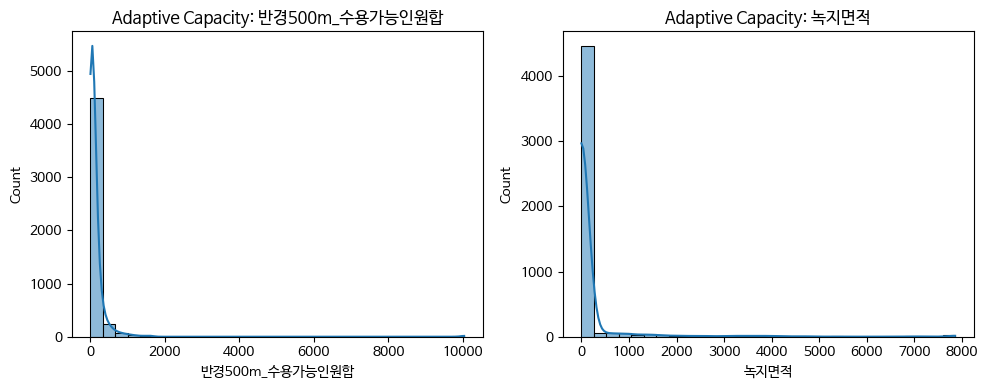

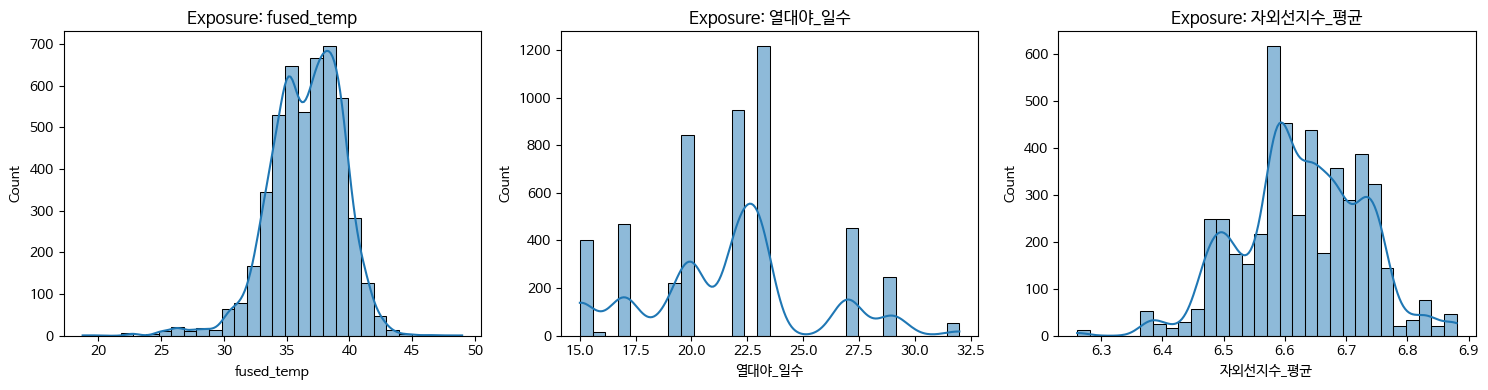

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화에 사용할 열들
columns_to_plot = {
    '유동인구': ['승차총승객수'],
    'Sensitivity': [
        '65세이상_인구비율', '국민기초_수급자비율', '독거노인_비율',
        '저소득노인_비율', '장애인_비율', '인구밀도', '주택 노후도'
    ],
    'Adaptive Capacity': ['반경500m_수용가능인원합', '녹지면적'],
    'Exposure': ['fused_temp', '열대야_일수', '자외선지수_평균']
}

# 시각화
for group, cols in columns_to_plot.items():
    num_cols = len(cols)
    plt.figure(figsize=(5 * num_cols, 4))
    for i, col in enumerate(cols):
        plt.subplot(1, num_cols, i + 1)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f'{group}: {col}')
    plt.tight_layout()
    plt.show()

In [10]:
# 녹지 면적에 대한 통계 요약
q1 = df['녹지면적'].quantile(0.25)
q2 = df['녹지면적'].quantile(0.50)
q3 = df['녹지면적'].quantile(0.75)
mean = df['녹지면적'].mean()

print(f"Q1 (25%): {q1}")
print(f"Q2 (Median): {q2}")
print(f"Q3 (75%): {q3}")
print(f"Mean (평균): {mean}")

print(df['녹지면적'].value_counts())

Q1 (25%): 0.0
Q2 (Median): 0.0
Q3 (75%): 0.0
Mean (평균): 189.71430623973728
녹지면적
0.00       4287
7854.00      16
7841.37       3
61.27         2
303.12        2
           ... 
3153.12       1
3474.67       1
1203.87       1
2983.11       1
1020.94       1
Name: count, Length: 565, dtype: int64


In [11]:
# 반경500m_수용가능인원합에 대한 통계 요약
q1 = df['반경500m_수용가능인원합'].quantile(0.25)
q2 = df['반경500m_수용가능인원합'].quantile(0.50)
q3 = df['반경500m_수용가능인원합'].quantile(0.75)
mean = df['반경500m_수용가능인원합'].mean()

# 출력
print(f"Q1 (25%): {q1}")
print(f"Q2 (Median): {q2}")
print(f"Q3 (75%): {q3}")
print(f"Mean (평균): {mean}")

# 값별 빈도 출력
print(df['반경500m_수용가능인원합'].value_counts())

Q1 (25%): 19.0
Q2 (Median): 50.0
Q3 (75%): 125.0
Mean (평균): 131.64983579638752
반경500m_수용가능인원합
0.0       827
20.0      251
30.0      198
50.0      189
10.0      147
         ... 
894.0       1
129.0       1
1457.0      1
961.0       1
974.0       1
Name: count, Length: 455, dtype: int64


In [12]:
import numpy as np

# 로그 변환할 열 목록
cols_to_log = [
    '승차총승객수',
    '국민기초_수급자비율', '독거노인_비율', '저소득노인_비율', '장애인_비율',
    '반경500m_수용가능인원합', '녹지면적'
]

# 각 열에 로그 변환 적용 (새 열로 저장: 원본은 그대로 보존)
for col in cols_to_log:
    df[f'log_{col}'] = np.log1p(df[col])

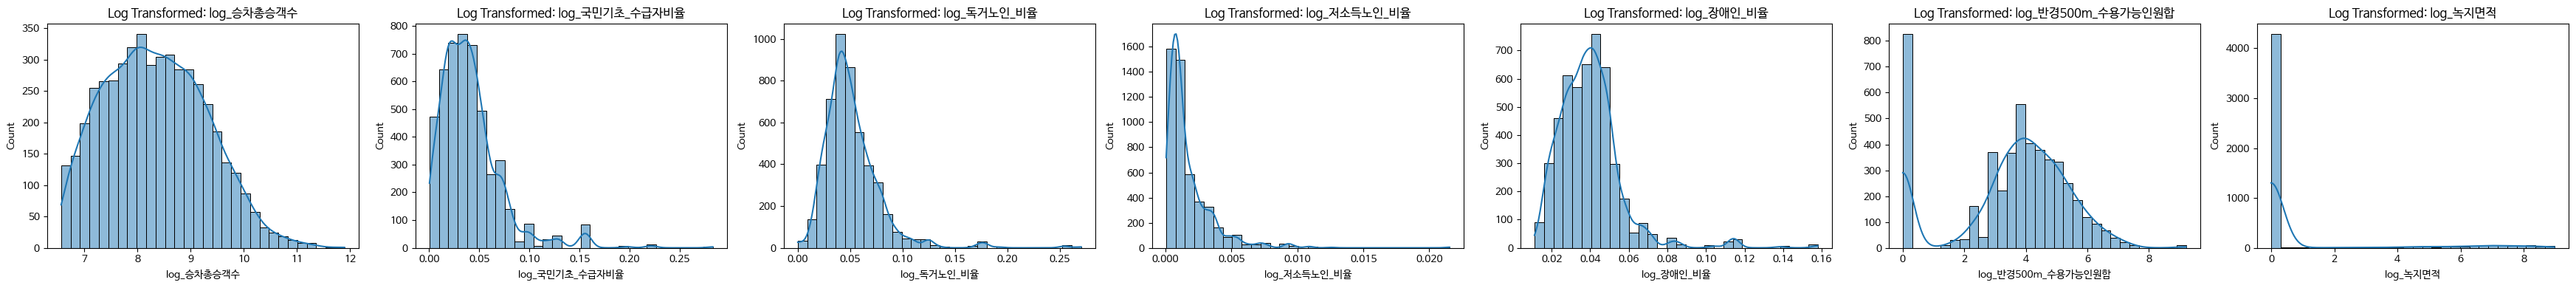

In [13]:
# 로그 변환한 열들 시각화
log_cols = [f'log_{col}' for col in cols_to_log]

num_cols = len(log_cols)
plt.figure(figsize=(5 * num_cols, 4))

for i, col in enumerate(log_cols):
    plt.subplot(1, num_cols, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Log Transformed: {col}')

plt.tight_layout()
plt.show()

### Data scaling

In [14]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# 사용할 컬럼 목록
columns_to_scale = [
    '65세이상_인구비율', 'log_국민기초_수급자비율', 'log_독거노인_비율', 'log_저소득노인_비율', 'log_장애인_비율', '인구밀도', '주택 노후도',
    'log_반경500m_수용가능인원합', 'log_녹지면적',
    'fused_temp', '열대야_일수', '자외선지수_평균'
]

# 스케일러 정의
scalers = {
    'std': StandardScaler(),
    'minmax': MinMaxScaler(),
    'robust': RobustScaler()
}

# 각 스케일러별로 열 생성해서 df에 직접 추가
for name, scaler in scalers.items():
    scaled_values = scaler.fit_transform(df[columns_to_scale])
    scaled_col_names = [f'{col}_{name}' for col in columns_to_scale]
    df[scaled_col_names] = scaled_values

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4872 entries, 0 to 10619
Data columns (total 79 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   표준버스정류장ID                  4872 non-null   int64  
 1   버스정류장ARS번호                 4872 non-null   int64  
 2   승차총승객수                     4872 non-null   int64  
 3   하차총승객수                     4872 non-null   int64  
 4   X좌표                        4872 non-null   float64
 5   Y좌표                        4872 non-null   float64
 6   정류소타입                      4872 non-null   object 
 7   승차_ID                      4872 non-null   float64
 8   총환승수                       4872 non-null   float64
 9   가중평균환승시간                   4872 non-null   float64
 10  스마트쉘터여부                    4872 non-null   int64  
 11  동                          4872 non-null   object 
 12  전체_인구수                     4872 non-null   int64  
 13  65세이상_인구수                  4872 non-null   int64  
 

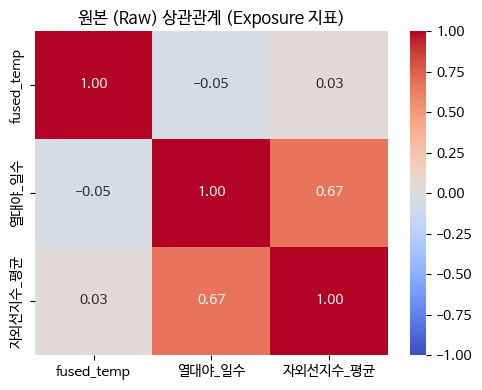

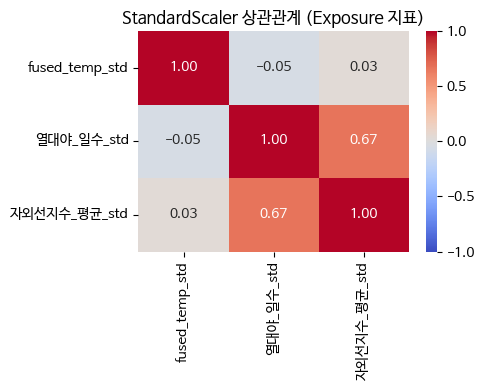

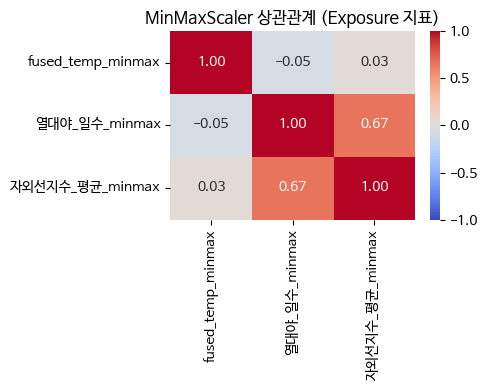

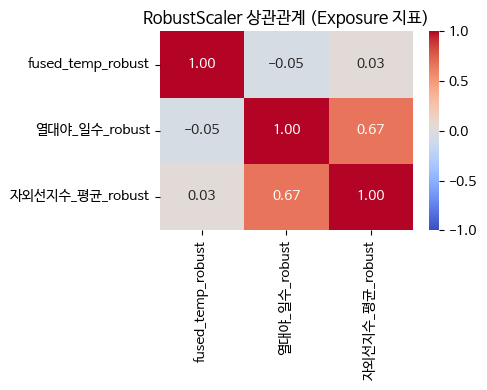

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Exposure 지표 열 이름
exposure_base = ['fused_temp', '열대야_일수', '자외선지수_평균']

# 🔹 스케일링된 열 이름 정리
exposure_scaled_cols = {
    '원본 (Raw)': exposure_base,
    'StandardScaler': [f"{col}_std" for col in exposure_base],
    'MinMaxScaler': [f"{col}_minmax" for col in exposure_base],
    'RobustScaler': [f"{col}_robust" for col in exposure_base]
}

# 🔹 시각화
for scaler_name, cols in exposure_scaled_cols.items():
    corr = df[cols].corr()
    plt.figure(figsize=(5, 4))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
    plt.title(f'{scaler_name} 상관관계 (Exposure 지표)')
    plt.tight_layout()
    plt.show()

In [16]:
# Exposure 지표 계산 (열대야와 자외선의 평균)
df['Exposure_std'] = (df['열대야_일수_std'] + df['자외선지수_평균_std']) / 2
df['Exposure_minmax'] = (df['열대야_일수_minmax'] + df['자외선지수_평균_minmax']) / 2
df['Exposure_robust'] = (df['열대야_일수_robust'] + df['자외선지수_평균_robust']) / 2

In [17]:
from sklearn.decomposition import PCA
import pandas as pd

# Sensitivity 관련 원본 열 (로그 포함)
sensitivity_features = [
    '65세이상_인구비율',
    'log_국민기초_수급자비율',
    'log_독거노인_비율',
    'log_저소득노인_비율',
    'log_장애인_비율',
    '인구밀도',
    '주택 노후도'
]

# 스케일링별 접미어
scaling_suffixes = {
    'StandardScaler': '_std',
    'MinMaxScaler': '_minmax',
    'RobustScaler': '_robust'
}

# 각 스케일링 방법별로 PCA 수행 및 결과 출력
for scaler_name, suffix in scaling_suffixes.items():
    scaled_cols = [col + suffix for col in sensitivity_features]
    pca = PCA()
    components = pca.fit_transform(df[scaled_cols])

    # 설명된 분산 비율 출력
    print(f"\n PCA 결과 ({scaler_name})")
    print("설명된 분산 비율 (Explained Variance Ratio):")
    for i, var in enumerate(pca.explained_variance_ratio_):
        print(f"  PC{i+1}: {var:.4f}")

    # 주성분 계수 출력
    loading_df = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(len(scaled_cols))],
        index=sensitivity_features
    )

    print("\n주성분 계수 (Loadings):")
    display(loading_df.round(3))


 PCA 결과 (StandardScaler)
설명된 분산 비율 (Explained Variance Ratio):
  PC1: 0.5396
  PC2: 0.1587
  PC3: 0.1322
  PC4: 0.0785
  PC5: 0.0568
  PC6: 0.0188
  PC7: 0.0154

주성분 계수 (Loadings):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
65세이상_인구비율,0.436,-0.009,-0.009,-0.096,0.813,0.070,-0.367
log_국민기초_수급자비율,0.457,0.055,0.026,-0.337,-0.480,-0.424,-0.513
log_독거노인_비율,0.478,0.061,0.068,-0.136,-0.284,0.806,0.125
log_저소득노인_비율,0.371,-0.034,-0.198,0.890,-0.126,-0.082,-0.083
log_장애인_비율,0.480,-0.159,-0.043,-0.168,0.091,-0.381,0.748
인구밀도,0.013,-0.677,0.721,0.118,-0.029,0.004,-0.079
주택 노후도,0.067,0.713,0.658,0.153,0.059,-0.120,0.112



 PCA 결과 (MinMaxScaler)
설명된 분산 비율 (Explained Variance Ratio):
  PC1: 0.4430
  PC2: 0.3695
  PC3: 0.0646
  PC4: 0.0586
  PC5: 0.0387
  PC6: 0.0132
  PC7: 0.0124

주성분 계수 (Loadings):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
65세이상_인구비율,0.575,-0.082,-0.274,0.711,-0.112,-0.191,0.182
log_국민기초_수급자비율,0.431,-0.075,0.280,-0.470,-0.290,-0.032,0.651
log_독거노인_비율,0.414,-0.057,0.239,-0.255,-0.003,-0.588,-0.598
log_저소득노인_비율,0.252,-0.052,-0.107,-0.148,0.931,0.012,0.182
log_장애인_비율,0.481,-0.017,-0.154,-0.167,-0.109,0.745,-0.387
인구밀도,0.128,0.989,0.047,0.017,0.024,-0.026,0.032
주택 노후도,0.037,-0.049,0.867,0.398,0.154,0.248,-0.036



 PCA 결과 (RobustScaler)
설명된 분산 비율 (Explained Variance Ratio):
  PC1: 0.5589
  PC2: 0.1872
  PC3: 0.1106
  PC4: 0.0650
  PC5: 0.0442
  PC6: 0.0204
  PC7: 0.0137

주성분 계수 (Loadings):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
65세이상_인구비율,0.334,-0.003,-0.124,0.028,0.802,0.033,-0.477
log_국민기초_수급자비율,0.448,0.055,-0.349,-0.168,-0.453,-0.527,-0.404
log_독거노인_비율,0.500,0.084,-0.227,-0.048,-0.253,0.790,0.035
log_저소득노인_비율,0.484,-0.179,0.842,0.088,-0.101,-0.071,-0.048
log_장애인_비율,0.444,-0.125,-0.242,0.076,0.240,-0.290,0.763
인구밀도,0.004,-0.078,-0.144,0.970,-0.130,-0.014,-0.122
주택 노후도,0.079,0.968,0.152,0.118,0.052,-0.090,0.098


In [18]:
from sklearn.decomposition import PCA

# Sensitivity 변수 목록
sensitivity_features = [
    '65세이상_인구비율',
    'log_국민기초_수급자비율',
    'log_독거노인_비율',
    'log_저소득노인_비율',
    'log_장애인_비율',
    '인구밀도',
    '주택 노후도'
]

# 스케일링 방식 접미어 매핑
scaling_suffixes = {
    'std': '_std',
    'minmax': '_minmax',
    'robust': '_robust'
}

# 첫 번째 주성분을 Sensitivity 지표로 저장
for suffix_key, suffix in scaling_suffixes.items():
    cols = [col + suffix for col in sensitivity_features]

    # PCA 수행
    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(df[cols])

    # 첫 번째 주성분을 Sensitivity 지표로 저장
    df[f'Sensitivity_{suffix_key}'] = pc1[:, 0]

In [19]:
# 사용 열
base_vars = ['log_반경500m_수용가능인원합', 'log_녹지면적']

# 스케일링 접미어
suffixes = {
    'std': '_std',
    'minmax': '_minmax',
    'robust': '_robust'
}

# 1. 각각 단일 지표 + 2. 평균 지표 계산
for scale_key, suffix in suffixes.items():
    # 각각 단일 지표 그대로 사용
    df[f'Adaptive_capacity_인원합_{scale_key}'] = df[base_vars[0] + suffix]
    df[f'Adaptive_capacity_녹지면적_{scale_key}'] = df[base_vars[1] + suffix]

    # 평균 계산
    df[f'Adaptive_capacity_평균_{scale_key}'] = (
        df[base_vars[0] + suffix] + df[base_vars[1] + suffix]
    ) / 2

In [20]:
df['Mobility'] = df['log_승차총승객수']

In [21]:
# 스케일링 방식 접미어들
scales = ['std', 'minmax', 'robust']

# Adaptive Capacity 방식 종류
ac_types = ['인원합', '녹지면적', '평균']

# VRI 계산 공식 적용
for scale in scales:
    exposure_col = f'Exposure_{scale}'
    sensitivity_col = f'Sensitivity_{scale}'

    for ac_type in ac_types:
        ac_col = f'Adaptive_capacity_{ac_type}_{scale}'
        vri_col = f'VRI_{scale}_{ac_type}'

        df[vri_col] = (
            df[exposure_col] + df[sensitivity_col] - 2 * df[ac_col]
        ) / 4

In [22]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 4872 entries, 0 to 10619
Data columns (total 104 columns):
 #    Column                         Dtype  
---   ------                         -----  
 0    표준버스정류장ID                      int64  
 1    버스정류장ARS번호                     int64  
 2    승차총승객수                         int64  
 3    하차총승객수                         int64  
 4    X좌표                            float64
 5    Y좌표                            float64
 6    정류소타입                          object 
 7    승차_ID                          float64
 8    총환승수                           float64
 9    가중평균환승시간                       float64
 10   스마트쉘터여부                        int64  
 11   동                              object 
 12   전체_인구수                         int64  
 13   65세이상_인구수                      int64  
 14   65세이상_인구비율                     float64
 15   국민기초_수급자수                      int64  
 16   국민기초_수급자비율                     float64
 17   자외선지수_평균                       floa

In [23]:
# VRI 관련 열들
vri_columns = [
    'VRI_std_인원합', 'VRI_std_녹지면적', 'VRI_std_평균',
    'VRI_minmax_인원합', 'VRI_minmax_녹지면적', 'VRI_minmax_평균',
    'VRI_robust_인원합', 'VRI_robust_녹지면적', 'VRI_robust_평균'
]

# 각 VRI 열과 Mobility를 곱해서 가중유동인구 열 생성
for col in vri_columns:
    df[f'가중유동인구_{col}'] = df['Mobility'] * df[col]

In [24]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 4872 entries, 0 to 10619
Data columns (total 113 columns):
 #    Column                         Dtype  
---   ------                         -----  
 0    표준버스정류장ID                      int64  
 1    버스정류장ARS번호                     int64  
 2    승차총승객수                         int64  
 3    하차총승객수                         int64  
 4    X좌표                            float64
 5    Y좌표                            float64
 6    정류소타입                          object 
 7    승차_ID                          float64
 8    총환승수                           float64
 9    가중평균환승시간                       float64
 10   스마트쉘터여부                        int64  
 11   동                              object 
 12   전체_인구수                         int64  
 13   65세이상_인구수                      int64  
 14   65세이상_인구비율                     float64
 15   국민기초_수급자수                      int64  
 16   국민기초_수급자비율                     float64
 17   자외선지수_평균                       floa

In [25]:
# T점수 변환 함수 정의
def to_t_score(series):
    return series * 10 + 50

# 대상 열 리스트
vri_cols = ['VRI_std_인원합', 'VRI_std_녹지면적', 'VRI_std_평균']

# 각 열에 대해 T점수로 변환해서 새 열로 추가
for col in vri_cols:
    new_col = col + '_T'
    df[new_col] = to_t_score(df[col])

In [26]:
# 가중유동인구 = Mobility × VRI_T
t_score_cols = [
    'VRI_std_인원합_T',
    'VRI_std_녹지면적_T',
    'VRI_std_평균_T'
]

# 새 열 이름 정의 및 계산
for col in t_score_cols:
    new_col = '가중유동인구_' + col
    df[new_col] = df['Mobility'] * df[col]

In [27]:
import pandas as pd

col = 'VRI_std_평균_T'

stats = {
    '최소값 (min)': df[col].min(),
    '1사분위수 (Q1)': df[col].quantile(0.25),
    '중앙값 (Q2 / median)': df[col].quantile(0.5),
    '평균 (mean)': df[col].mean(),
    '3사분위수 (Q3)': df[col].quantile(0.75),
    '최대값 (max)': df[col].max()
}

# DataFrame으로 변환
stats_df = pd.DataFrame(stats.items(), columns=['구분', '값']).round(3)

# 보기 좋게 출력
from IPython.display import display
display(stats_df)

,구분,값
0,최소값 (min),27.388
1,1사분위수 (Q1),46.583
2,중앙값 (Q2 / median),49.723
3,평균 (mean),50.000
4,3사분위수 (Q3),52.814
5,최대값 (max),85.786


In [28]:
import pandas as pd

col = '가중유동인구_VRI_std_평균_T'

stats = {
    '최소값 (min)': df[col].min(),
    '1사분위수 (Q1)': df[col].quantile(0.25),
    '중앙값 (Q2 / median)': df[col].quantile(0.5),
    '평균 (mean)': df[col].mean(),
    '3사분위수 (Q3)': df[col].quantile(0.75),
    '최대값 (max)': df[col].max()
}

# DataFrame으로 변환
stats_df = pd.DataFrame(stats.items(), columns=['구분', '값']).round(3)

# 보기 좋게 출력
from IPython.display import display
display(stats_df)

,구분,값
0,최소값 (min),184.889
1,1사분위수 (Q1),370.593
2,중앙값 (Q2 / median),412.861
3,평균 (mean),417.243
4,3사분위수 (Q3),459.040
5,최대값 (max),873.372


### MCLP

In [34]:
def apply_mclp(df, demand_col='가중유동인구_VRI_std_평균', radius=500, top_n=200):
    # Step 1: 후보지 필터링 (스마트쉘터가 없는 곳)
    candidates = df[df['스마트쉘터여부'] == 0].copy().reset_index(drop=True)

    # 위경도 변환 (거리 계산을 위해 radians로 변환)
    coords_rad = np.radians(candidates[['Y좌표', 'X좌표']].values)

    # Step 2: 거리 행렬 계산 (단위: km -> 500m = 0.5km)
    distance_matrix = haversine_distances(coords_rad, coords_rad) * 6371000  # 지구 반지름 (m)

    # Step 3: 영향 범위 내 인덱스 리스트 구축
    coverage_dict = {}
    for i, row in candidates.iterrows():
        covered = np.where(distance_matrix[i] <= radius)[0].tolist()
        coverage_dict[i] = covered

    # Step 4: Greedy MCLP - 최대 커버리지 기준으로 후보 선택
    selected = []
    covered_demand = set()
    all_indices = set(range(len(candidates)))

    while len(selected) < top_n and len(covered_demand) < len(all_indices):
        best_candidate = None
        best_coverage_gain = -1

        for i in all_indices - set(selected):
            coverage = set(coverage_dict[i]) - covered_demand
            gain = candidates.loc[list(coverage), demand_col].sum()

            if gain > best_coverage_gain:
                best_coverage_gain = gain
                best_candidate = i

        if best_candidate is None:
            break  # 더 이상 커버할 수 있는 수요지가 없음

        selected.append(best_candidate)
        covered_demand.update(coverage_dict[best_candidate])

    # Step 5: 결과 반환
    selected_stops = candidates.loc[selected].copy()
    selected_stops['선정순위'] = range(1, len(selected) + 1)

    return selected_stops

In [31]:
result = apply_mclp(df)
print(result[['표준버스정류장ID', '가중유동인구_VRI_std_평균', '선정순위']])

      표준버스정류장ID  가중유동인구_VRI_std_평균  선정순위
2781  115000165          14.988714     1
3172  117000087           6.313397     2
2681  115000013          12.634458     3
248   101000263          12.074355     4
4271  122000294          26.166803     5
...         ...                ...   ...
659   104000119           1.127917   196
3637  120000034          -2.136086   197
3625  120000017           5.164848   198
3494  119000063           5.288206   199
3976  121001338           3.101216   200

[200 rows x 3 columns]


In [ ]:
def apply_mclp_5m(df, demand_col='가중유동인구_VRI_std_평균', radius=500, top_n=200):
    """
    MCLP 알고리즘 적용 함수
    - 쉘터가 없는 버스정류장 중 5m 이내 설치 가능한 곳만 후보로 사용
    - 수요량 기준 최대 커버되는 상위 top_n개 선정
    """
    # ✅ 후보지 필터링: 쉘터 없음 & 5m 가능 지역만
    candidates = df[(df['스마트쉘터여부'] == 0) & (df['5m 여부'] == 1)].copy().reset_index(drop=True)

    # 위경도 변환 (거리 계산을 위해 radians로 변환)
    coords_rad = np.radians(candidates[['Y좌표', 'X좌표']].values)

    # 거리 행렬 (단위: m)
    from sklearn.metrics.pairwise import haversine_distances
    distance_matrix = haversine_distances(coords_rad, coords_rad) * 6371000  # 지구 반지름 = 6371km → m

    # 영향 반경 내 수요지 목록 만들기
    coverage_dict = {}
    for i in range(len(candidates)):
        covered = np.where(distance_matrix[i] <= radius)[0].tolist()
        coverage_dict[i] = covered

    # Greedy MCLP
    selected = []
    covered_demand = set()
    all_indices = set(range(len(candidates)))

    while len(selected) < top_n and len(covered_demand) < len(all_indices):
        best_candidate = None
        best_gain = -1

        for i in all_indices - set(selected):
            coverage = set(coverage_dict[i]) - covered_demand
            gain = candidates.loc[list(coverage), demand_col].sum()

            if gain > best_gain:
                best_gain = gain
                best_candidate = i

        if best_candidate is None:
            break

        selected.append(best_candidate)
        covered_demand.update(coverage_dict[best_candidate])

    # 최종 선정된 정류장 반환
    result = candidates.loc[selected].copy()
    result['선정순위'] = range(1, len(result) + 1)

    return result

In [ ]:
result_5m = apply_mclp(df)
print(result_5m[['표준버스정류장ID', '가중유동인구_VRI_std_평균', '선정순위']])

### 시각화

In [35]:
## MCLP 알고리즘 단독 시각화

def visualize_shelters_map(df_selected, radius=500):
    """
    df_selected: apply_mclp() 결과 데이터프레임
    radius: 원 반경 (단위: meter)
    """
    # 중심 좌표 설정 (첫 번째 정류장 기준)
    center_lat = df_selected['Y좌표'].mean()
    center_lon = df_selected['X좌표'].mean()

    # 지도 생성
    m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

    # 마커 클러스터 추가
    marker_cluster = MarkerCluster().add_to(m)

    for idx, row in df_selected.iterrows():
        lat = row['Y좌표']
        lon = row['X좌표']
        stop_id = row['표준버스정류장ID']
        score = row['가중유동인구_VRI_std_평균']
        rank = row['선정순위']

        # 정류장 마커
        folium.Marker(
            location=[lat, lon],
            popup=f"정류장 ID: {stop_id}<br>순위: {rank}<br>수요점수: {score:.2f}",
            icon=folium.Icon(color="blue", icon="info-sign")
        ).add_to(marker_cluster)

        # 영향 반경 (500m)
        folium.Circle(
            location=[lat, lon],
            radius=radius,
            color="blue",
            fill=True,
            fill_opacity=0.1
        ).add_to(m)

    return m

In [36]:
# MCLP 선정 결과 가져오기
selected_stops = apply_mclp(df)

# 시각화
map_result = visualize_shelters_map(selected_stops)
map_result.save("shelter_map.html")  # 파일로 저장
map_result  # 주피터 노트북 환경에서는 이 라인만으로 지도 표시됨

In [37]:
## top k & MCLP 알고리즘 비교 시각화

import folium
from folium.plugins import MarkerCluster

def compare_mclp_and_top200(df, mclp_result, demand_col='가중유동인구_VRI_std_평균', radius=500):
    """
    df: 전체 데이터 (스마트쉘터 없는 정류장 포함)
    mclp_result: apply_mclp() 결과 (MCLP로 선정된 정류장 200개)
    demand_col: 수요량 컬럼명
    radius: 영향 반경 (m)
    """
    # 1. 스마트쉘터 없는 정류장에서 단순 수요량 상위 200개 선정
    top200 = df[df['스마트쉘터여부'] == 0].copy()
    top200 = top200.sort_values(by=demand_col, ascending=False).head(200).reset_index(drop=True)
    top200['선정방식'] = 'Top200'

    # MCLP 결과에 방식 추가
    mclp = mclp_result.copy()
    mclp['선정방식'] = 'MCLP'

    # 지도 중심 설정
    center_lat = df['Y좌표'].mean()
    center_lon = df['X좌표'].mean()
    m = folium.Map(location=[center_lat, center_lon], zoom_start=13)

    # 마커 클러스터
    mclp_cluster = MarkerCluster(name='MCLP 선정').add_to(m)
    top200_cluster = MarkerCluster(name='Top200 선정').add_to(m)

    # 2. MCLP 선정 정류장 표시 (파란색)
    for idx, row in mclp.iterrows():
        lat, lon = row['Y좌표'], row['X좌표']
        popup = f"MCLP 순위: {row['선정순위']}<br>ID: {row['표준버스정류장ID']}<br>수요: {row[demand_col]:.2f}"
        folium.Marker(
            location=[lat, lon],
            popup=popup,
            icon=folium.Icon(color="blue", icon="flag")
        ).add_to(mclp_cluster)

        folium.Circle(
            location=[lat, lon],
            radius=radius,
            color="blue",
            fill=True,
            fill_opacity=0.1
        ).add_to(m)

    # 3. Top 200 수요량 기준 정류장 표시 (빨간색)
    for idx, row in top200.iterrows():
        lat, lon = row['Y좌표'], row['X좌표']
        popup = f"Top200 순위: {idx+1}<br>ID: {row['표준버스정류장ID']}<br>수요: {row[demand_col]:.2f}"
        folium.Marker(
            location=[lat, lon],
            popup=popup,
            icon=folium.Icon(color="red", icon="info-sign")
        ).add_to(top200_cluster)

        folium.Circle(
            location=[lat, lon],
            radius=radius,
            color="red",
            fill=True,
            fill_opacity=0.1
        ).add_to(m)

    folium.LayerControl().add_to(m)

    return m

In [38]:
# 1. MCLP 적용
mclp_result = apply_mclp(df)

# 2. 비교 시각화 지도 생성
comparison_map = compare_mclp_and_top200(df, mclp_result)

# 3. 저장 또는 Jupyter에서 시각화
comparison_map.save("mclp_vs_top200.html")
comparison_map